# Mean Squared Error

This is an optional practice notebook for lecture 1: it is not graded and not part of assignment 1.
Suggested order: this notebook first, then categorical cross-entropy, then the vanilla training loop, which builds on the MSE defined here.
It shows the mean squared error (MSE) in code, on the same data as the lecture slides.

The MSE is the objective function most often used in *regression* problems.
It measures how far the predictions of a model are from the labels.
For $N$ examples with inputs $x_n$, labels $y_n$, and predictions $\hat{y}_n = f(x_n)$, it is defined as

$$
\mathrm{MSE} = \frac{1}{N} \sum_{n=1}^{N} (y_n - \hat{y}_n)^2 .
$$

Squaring makes every error positive, so errors cannot cancel out, and it penalizes large errors more than small ones.
The MSE is zero exactly when every prediction equals its label.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

Let's write the MSE as a function.
Both arguments are arrays with one entry per example, and the mean runs over the examples.

In [2]:
def mse(y, y_pred):
    """Return the mean squared error between labels and predictions.

    Args:
        y: Array of labels, one per example.
        y_pred: Array of predictions, same shape as `y`.

    Returns:
        The average squared difference.
    """
    return np.mean((y - y_pred) ** 2)

## A toy dataset

We draw $N = 40$ inputs on $[0, 2\pi]$ and label them with a sine curve plus a little Gaussian noise.
The noise stands in for imperfect measurements.
A fixed seed makes the numbers reproducible, so your outputs should match the ones stored in this notebook and the figures on the slides.

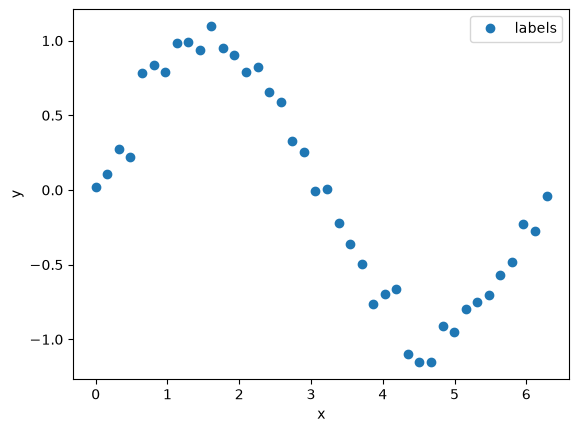

In [3]:
rng = np.random.default_rng(2)
N = 40

x = np.linspace(0, 2 * np.pi, N)
y = np.sin(x) + rng.normal(0, 0.1, N)

plt.plot(x, y, "o", label="labels")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## A good model

Suppose a machine learning algorithm has found the function $f(x) = \sin(x)$.
Its predictions follow the labels closely, and the only error left is the noise.

MSE = 0.0088


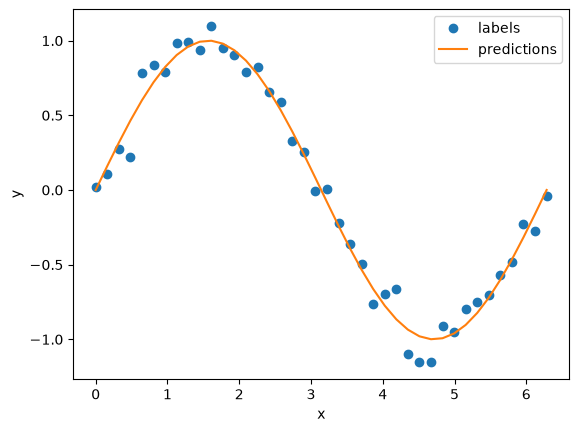

In [4]:
y_pred = np.sin(x)
print(f"MSE = {mse(y, y_pred):.4f}")

plt.plot(x, y, "o", label="labels")
plt.plot(x, y_pred, "-", label="predictions")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## A slightly worse model

Now suppose the algorithm found $f(x) = 0.8 \sin(x)$ instead.
The shape is right but the amplitude is off, and the MSE grows.

MSE = 0.0287


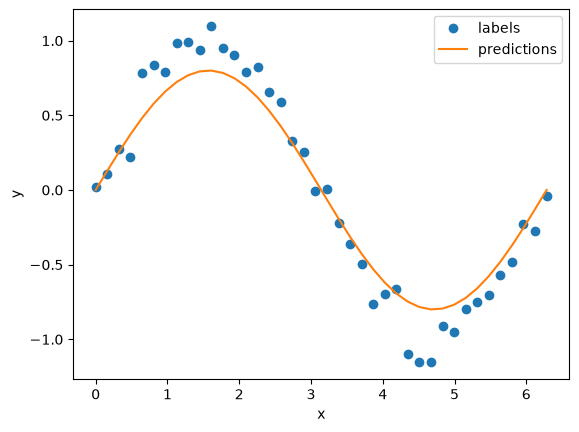

In [5]:
y_pred = 0.8 * np.sin(x)
print(f"MSE = {mse(y, y_pred):.4f}")

plt.plot(x, y, "o", label="labels")
plt.plot(x, y_pred, "-", label="predictions")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## A bad model

Finally, suppose the algorithm found a straight line, $f(x) = 0.3x - 1$, which has nothing to do with the data.

MSE = 1.3955


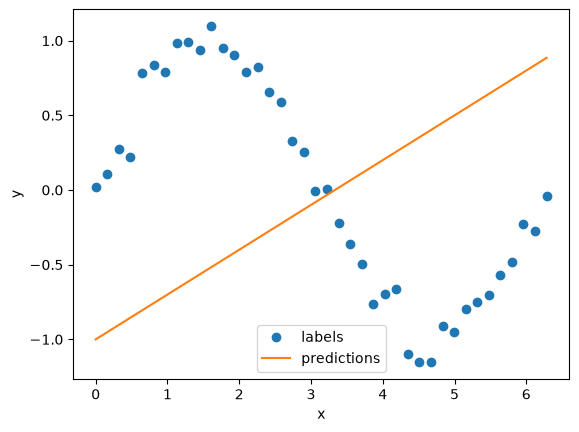

In [6]:
y_pred = 0.3 * x - 1
print(f"MSE = {mse(y, y_pred):.4f}")

plt.plot(x, y, "o", label="labels")
plt.plot(x, y_pred, "-", label="predictions")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

The MSE is much larger for the bad model.
It is zero only if the predictions reproduce the labels exactly, noise included:

In [7]:
print(f"MSE = {mse(y, y):.4f}")

MSE = 0.0000


## Summary

The MSE is a simple objective function that tells us how good a candidate solution is in a regression problem.
Smaller is better, and zero means a perfect fit of the training labels.
Lecture 1 uses it to compare candidate lines in the vanilla training loop.